Partie 1 — Importation et nettoyage

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Le fichier est un CSV dans le zip telecharge
# Apres extraction, le fichier s'appelle globalpowerplantdatabasev130.csv
df = pd.read_csv('globalpowerplantdatabasev130.csv')

print("Dimensions :", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())
print("\nApercu des donnees :")
display(df.head())

# On regarde les valeurs manquantes dans chaque colonne
print("\nValeurs manquantes par colonne :")
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes[valeurs_manquantes > 0])

# On supprime les doublons
df = df.drop_duplicates()

# La colonne capacity_mw (puissance en megawatts) est la plus importante
# On supprime les lignes ou cette valeur est manquante car on ne peut pas l'estimer
df = df.dropna(subset=['capacity_mw'])

# Pour les autres colonnes numeriques on remplace les manquants par la mediane
# La mediane est plus robuste que la moyenne face aux valeurs extremes
colonnes_numeriques = ['latitude', 'longitude', 'commissioning_year']
for col in colonnes_numeriques:
    if col in df.columns:
        mediane = df[col].median()
        df[col] = df[col].fillna(mediane)

# On s'assure que les colonnes numeriques sont bien en format numerique
df['capacity_mw'] = pd.to_numeric(df['capacity_mw'], errors='coerce')
df['latitude']    = pd.to_numeric(df['latitude'],    errors='coerce')
df['longitude']   = pd.to_numeric(df['longitude'],   errors='coerce')

print(f"\nDimensions apres nettoyage : {df.shape}")
print(f"Types des colonnes :\n{df.dtypes}")

Dimensions : (34936, 36)

Colonnes disponibles :
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']

Apercu des donnees :


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1



Valeurs manquantes par colonne :
other_fuel1                      32992
other_fuel2                      34660
other_fuel3                      34844
commissioning_year               17489
owner                            14068
source                              15
url                                 18
geolocation_source                 419
wepp_id                          18702
year_of_capacity_data            20049
generation_gwh_2013              28519
generation_gwh_2014              27710
generation_gwh_2015              26733
generation_gwh_2016              25792
generation_gwh_2017              25436
generation_gwh_2018              25299
generation_gwh_2019              25277
generation_data_source           23536
estimated_generation_gwh_2013    18816
estimated_generation_gwh_2014    18433
estimated_generation_gwh_2015    17886
estimated_generation_gwh_2016    17366
estimated_generation_gwh_2017     1798
dtype: int64

Dimensions apres nettoyage : (34936, 36)
Types des colo

Partie 2 — Analyse exploratoire

=== STATISTIQUES CLES ===



,capacity_mw,latitude,longitude
count,34936.00,34936.00,34936.00
mean,163.36,32.82,-6.97
std,489.64,22.64,78.41
min,1.00,-77.85,-179.98
25%,4.90,29.26,-77.64
50%,16.74,39.73,-2.13
75%,75.34,46.26,49.50
max,22500.00,71.29,179.39



Top 15 pays par nombre de centrales :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Japan                        522
Australia                    486
Portugal                     469
Czech Republic               462
Italy                        396
Name: count, dtype: int64

Repartition par type de combustible :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dt

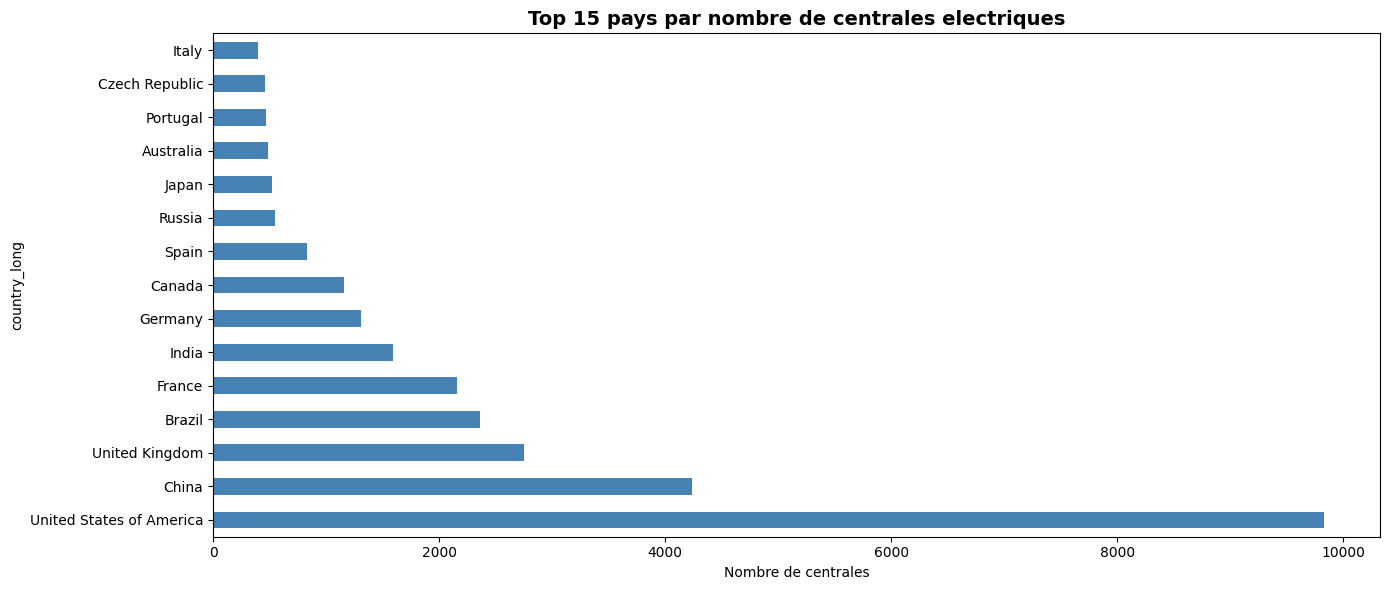

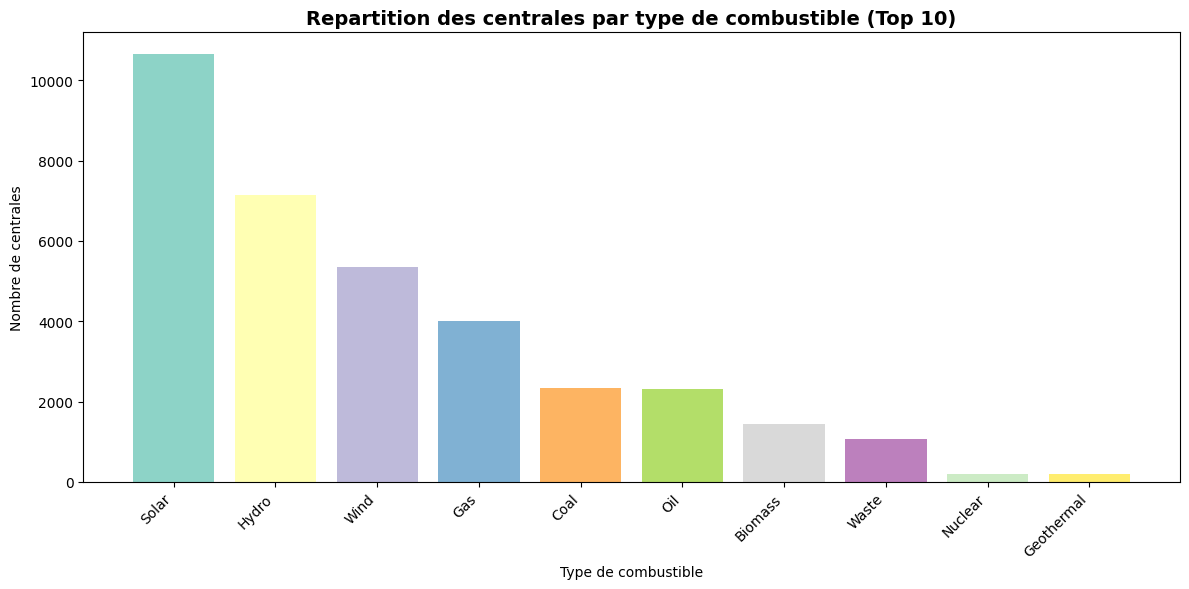

In [4]:
print("=== STATISTIQUES CLES ===\n")

# .describe() donne min, max, moyenne, ecart type etc.
display(df[['capacity_mw', 'latitude', 'longitude']].describe().round(2))

# Repartition par pays : top 15
print("\nTop 15 pays par nombre de centrales :")
top_pays = df['country_long'].value_counts().head(15)
print(top_pays)

# Repartition par type de combustible
print("\nRepartition par type de combustible :")
print(df['primary_fuel'].value_counts())

# Visualisation de la repartition par pays
plt.figure(figsize=(14, 6))
top_pays.plot(kind='barh', color='steelblue')
plt.title('Top 15 pays par nombre de centrales electriques',
          fontsize=14, fontweight='bold')
plt.xlabel('Nombre de centrales')
plt.tight_layout()
plt.show()

# Visualisation par type de combustible
plt.figure(figsize=(12, 6))
fuel_counts = df['primary_fuel'].value_counts().head(10)
colors = plt.cm.Set3(np.linspace(0, 1, len(fuel_counts)))
plt.bar(fuel_counts.index, fuel_counts.values, color=colors)
plt.title('Repartition des centrales par type de combustible (Top 10)',
          fontsize=14, fontweight='bold')
plt.xlabel('Type de combustible')
plt.ylabel('Nombre de centrales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Partie 3 — Analyse statistique

=== ANALYSE STATISTIQUE PAR TYPE DE COMBUSTIBLE ===

Statistiques de capacite (MW) par type de combustible :


,Moyenne,Mediane,Ecart_type,Max,Comptage
primary_fuel,,,,,
Nuclear,2091.86,1888.00,1303.51,8212.00,195
Coal,843.58,600.00,888.19,7000.00,2330
Gas,373.45,147.50,560.93,8865.00,3998
Petcoke,202.05,65.49,476.99,1707.30,12
Hydro,147.17,20.00,549.81,22500.00,7156
Oil,112.88,9.00,392.01,6794.00,2320
Cogeneration,98.73,31.90,283.43,1404.00,41
Other,84.02,40.00,145.89,845.26,43
Geothermal,67.13,30.00,114.64,1163.00,189



Test d'hypothese : Solaire vs Nucleaire
Moyenne solaire   : 17.66 MW
Moyenne nucleaire : 2091.86 MW
Score t           : -160.2417
P-value           : 0.000000
Conclusion : difference SIGNIFICATIVE entre solaire et nucleaire


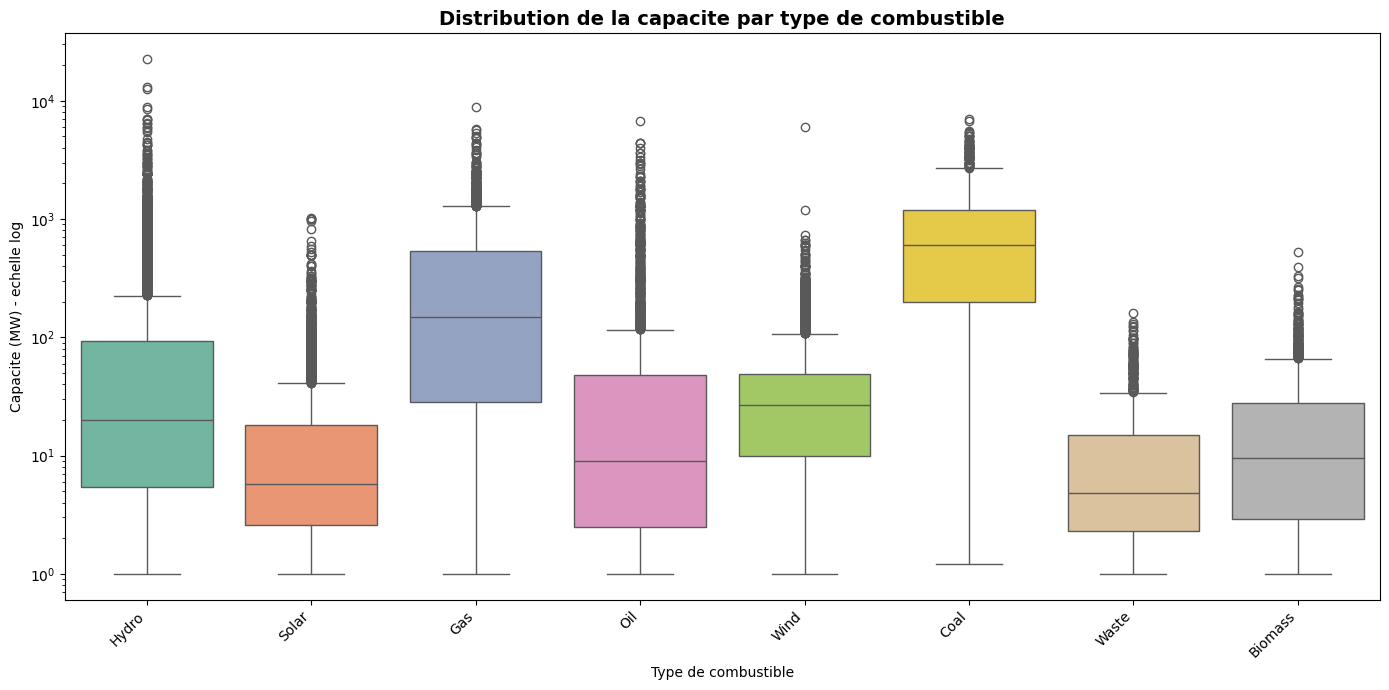

In [5]:
print("=== ANALYSE STATISTIQUE PAR TYPE DE COMBUSTIBLE ===\n")

# On regroupe les capacites par type de combustible
fuel_capacity = df.groupby('primary_fuel')['capacity_mw']

# Statistiques NumPy pour chaque type de combustible
stats_fuel = pd.DataFrame({
    'Moyenne'   : fuel_capacity.mean().round(2),
    'Mediane'   : fuel_capacity.median().round(2),
    'Ecart_type': fuel_capacity.std().round(2),
    'Max'       : fuel_capacity.max().round(2),
    'Comptage'  : fuel_capacity.count()
}).sort_values('Moyenne', ascending=False)

print("Statistiques de capacite (MW) par type de combustible :")
display(stats_fuel.head(10))

# Test d'hypothese : la capacite moyenne differe-t-elle entre solaire et eolien ?
# Hypothese : les centrales nucleaires ont une capacite moyenne differente
# des centrales solaires

solaire  = df[df['primary_fuel'] == 'Solar']['capacity_mw'].dropna()
nucleaire = df[df['primary_fuel'] == 'Nuclear']['capacity_mw'].dropna()

if len(solaire) > 1 and len(nucleaire) > 1:
    t_stat, p_value = stats.ttest_ind(solaire, nucleaire)
    print(f"\nTest d'hypothese : Solaire vs Nucleaire")
    print(f"Moyenne solaire   : {solaire.mean():.2f} MW")
    print(f"Moyenne nucleaire : {nucleaire.mean():.2f} MW")
    print(f"Score t           : {t_stat:.4f}")
    print(f"P-value           : {p_value:.6f}")

    # Si p_value < 0.05 la difference est statistiquement significative
    if p_value < 0.05:
        print("Conclusion : difference SIGNIFICATIVE entre solaire et nucleaire")
    else:
        print("Conclusion : pas de difference significative")

# Boxplot pour visualiser la distribution des capacites par combustible
plt.figure(figsize=(14, 7))

# On garde les 8 types de combustible les plus frequents
top_fuels = df['primary_fuel'].value_counts().head(8).index
df_top = df[df['primary_fuel'].isin(top_fuels)]

sns.boxplot(data=df_top, x='primary_fuel', y='capacity_mw',
            palette='Set2')
plt.yscale('log')  # echelle logarithmique car les valeurs sont tres dispersees
plt.title('Distribution de la capacite par type de combustible',
          fontsize=14, fontweight='bold')
plt.xlabel('Type de combustible')
plt.ylabel('Capacite (MW) - echelle log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Partie 4 — Analyse des series temporelles

=== ANALYSE TEMPORELLE ===



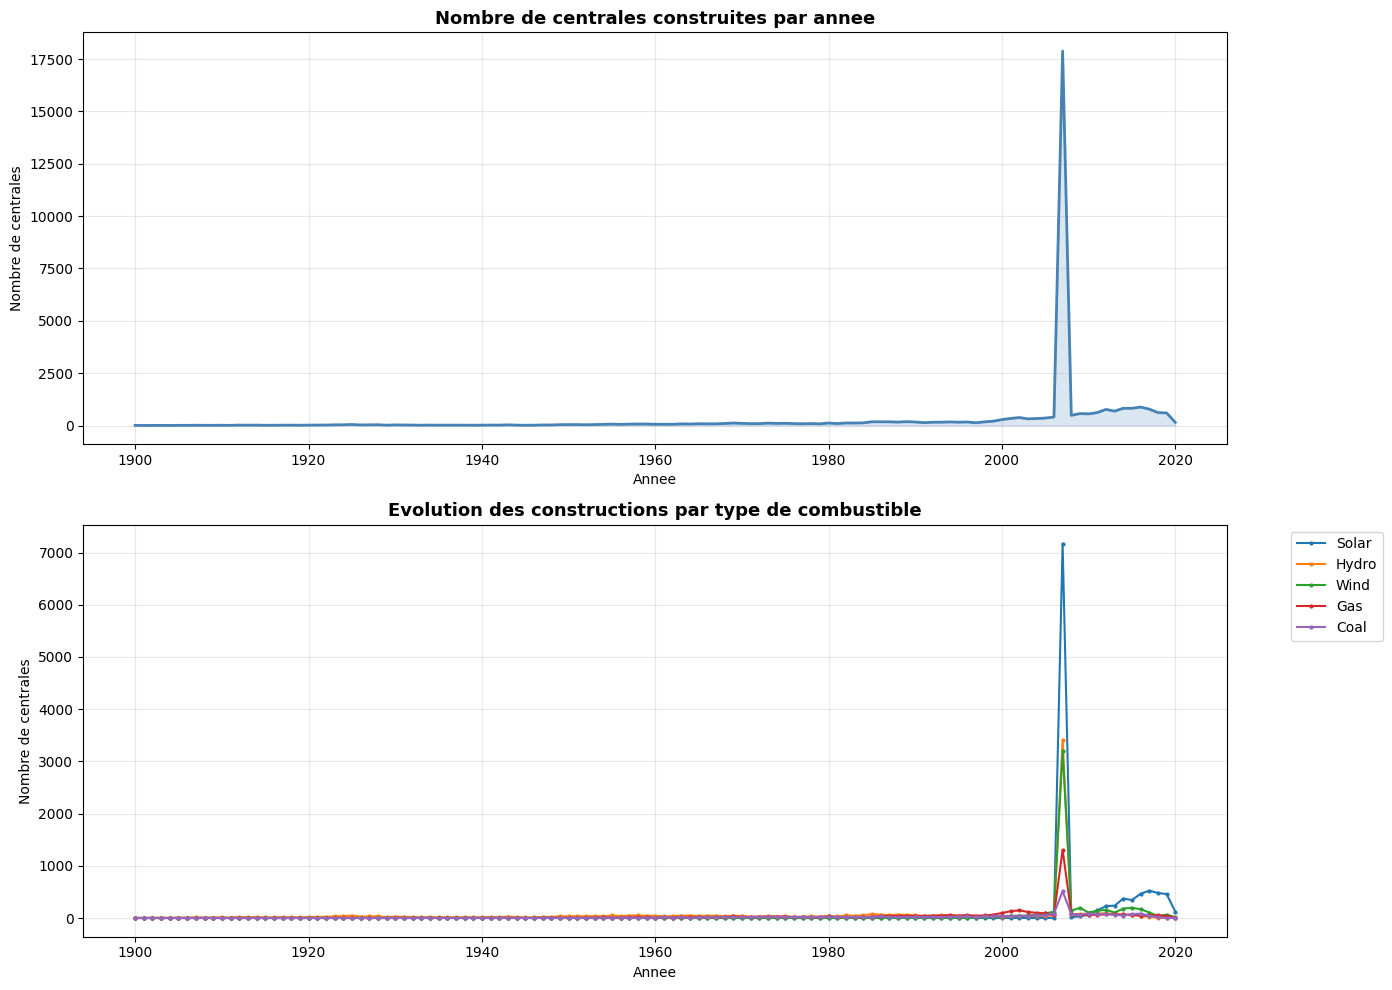

In [6]:
print("=== ANALYSE TEMPORELLE ===\n")

# On filtre les annees valides (entre 1900 et 2023)
df_annee = df[(df['commissioning_year'] >= 1900) &
              (df['commissioning_year'] <= 2023)].copy()

df_annee['commissioning_year'] = df_annee['commissioning_year'].astype(int)

# Nombre de centrales construites par annee
constructions_par_an = df_annee.groupby('commissioning_year').size()

# Evolution de la capacite totale installee par annee
capacite_par_an = df_annee.groupby('commissioning_year')['capacity_mw'].sum()

# Evolution par type de combustible au fil du temps
fuel_annee = (df_annee.groupby(['commissioning_year', 'primary_fuel'])
                      .size()
                      .unstack(fill_value=0))

# On garde les 5 types de combustible les plus representes
top_5_fuels = df['primary_fuel'].value_counts().head(5).index
fuel_annee_top5 = fuel_annee[top_5_fuels]

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : nombre de constructions par annee
ax1.plot(constructions_par_an.index, constructions_par_an.values,
         color='steelblue', linewidth=2)
ax1.fill_between(constructions_par_an.index, constructions_par_an.values,
                 alpha=0.2, color='steelblue')
ax1.set_title('Nombre de centrales construites par annee',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Annee')
ax1.set_ylabel('Nombre de centrales')
ax1.grid(True, alpha=0.3)

# Graphique 2 : evolution par type de combustible
for fuel in top_5_fuels:
    if fuel in fuel_annee_top5.columns:
        ax2.plot(fuel_annee_top5.index, fuel_annee_top5[fuel],
                 marker='o', markersize=2, linewidth=1.5, label=fuel)

ax2.set_title('Evolution des constructions par type de combustible',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Annee')
ax2.set_ylabel('Nombre de centrales')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Partie 5 — Visualisation avancee

=== VISUALISATIONS AVANCEES ===



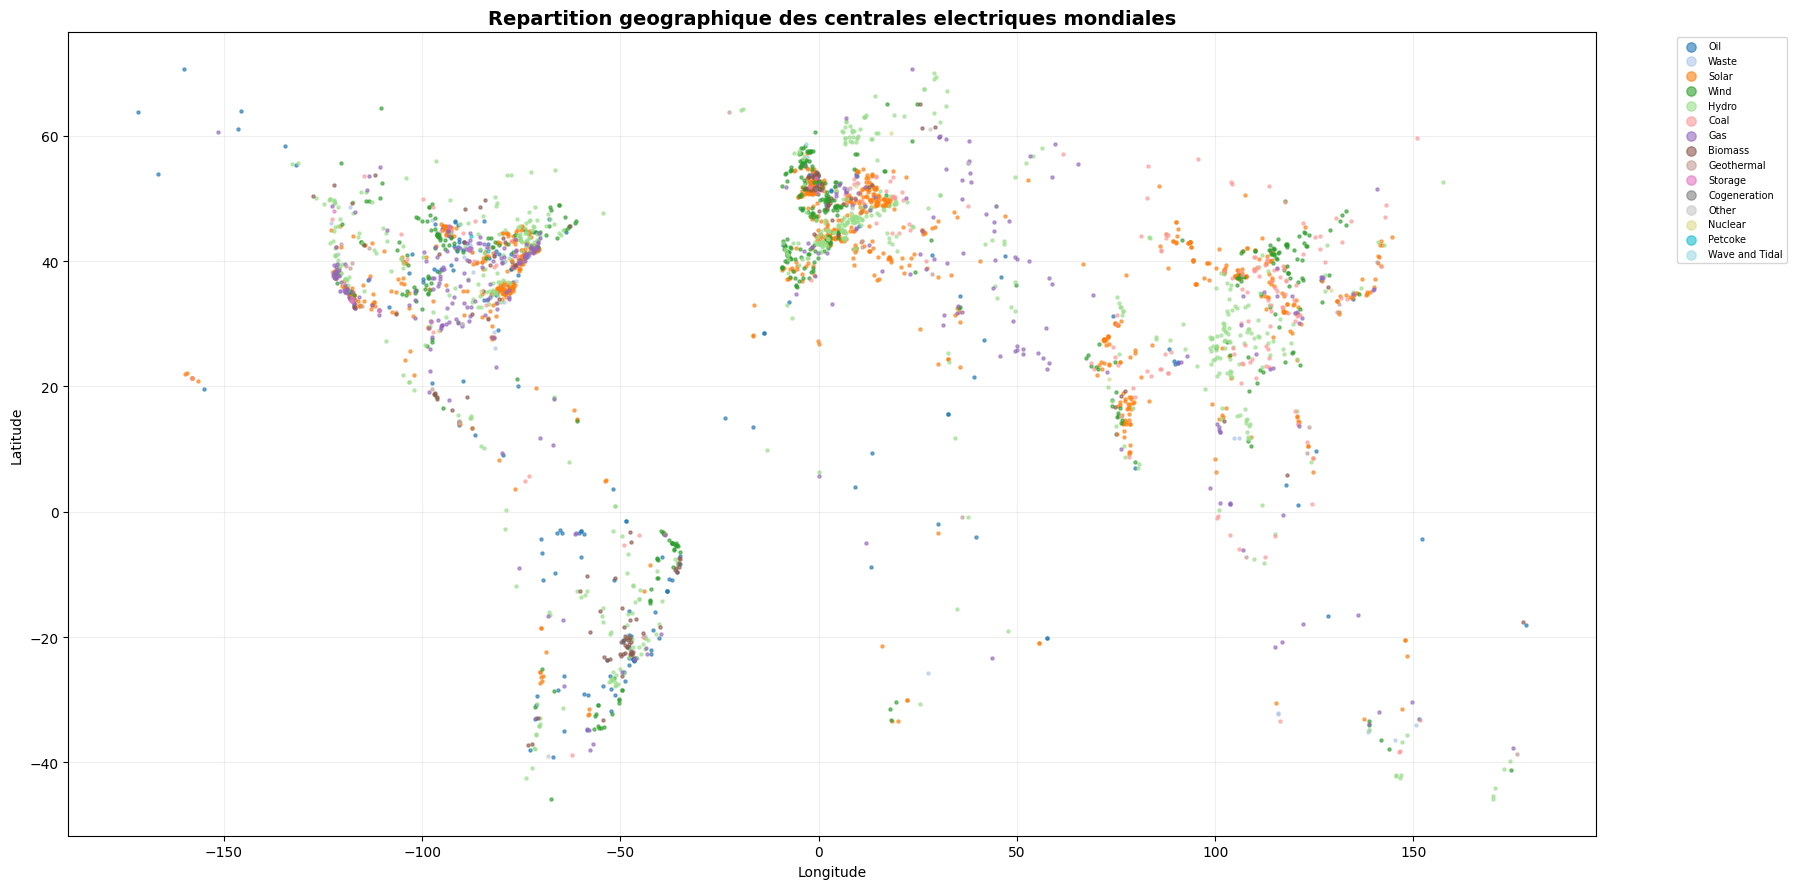

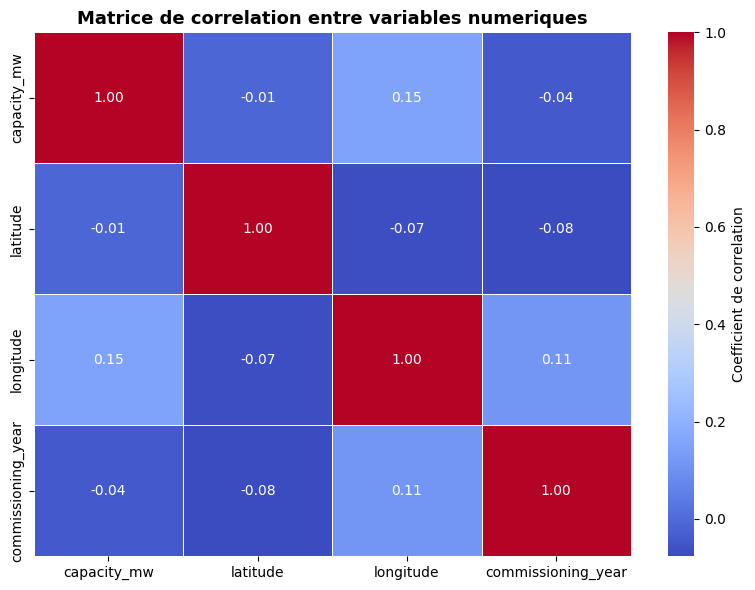

In [7]:
print("=== VISUALISATIONS AVANCEES ===\n")

# Carte geographique des centrales
# On utilise un echantillon de 3000 pour ne pas surcharger le graphique
df_sample = df.dropna(subset=['latitude', 'longitude']).sample(3000, random_state=42)

plt.figure(figsize=(18, 9))

# On colorie chaque type de combustible avec une couleur differente
fuels_uniques = df_sample['primary_fuel'].unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(fuels_uniques)))
color_map = dict(zip(fuels_uniques, palette))

for fuel in fuels_uniques:
    mask = df_sample['primary_fuel'] == fuel
    subset = df_sample[mask]
    plt.scatter(subset['longitude'], subset['latitude'],
                c=[color_map[fuel]], label=fuel,
                s=5, alpha=0.6)

plt.title('Repartition geographique des centrales electriques mondiales',
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=7, markerscale=3)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Heatmap de correlation entre variables numeriques
plt.figure(figsize=(8, 6))
colonnes_corr = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
colonnes_dispo = [c for c in colonnes_corr if c in df.columns]

# .corr() calcule le coefficient de correlation entre chaque paire de colonnes
# 1 = correlation parfaite, 0 = aucune correlation, -1 = correlation inverse
matrice_corr = df[colonnes_dispo].corr()

sns.heatmap(matrice_corr, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Coefficient de correlation'})
plt.title('Matrice de correlation entre variables numeriques',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Partie 6 — Operations matricielles

In [8]:
print("=== OPERATIONS MATRICIELLES ===\n")

# On cree une matrice numerique avec les colonnes disponibles
# pour analyser les relations entre attributs
colonnes_matrice = ['capacity_mw', 'latitude', 'longitude']
df_matrice = df[colonnes_matrice].dropna().head(100)

# On normalise les donnees : on soustrait la moyenne et divise par l'ecart type
# Cela met toutes les colonnes sur la meme echelle
df_normalise = (df_matrice - df_matrice.mean()) / df_matrice.std()
matrice_np = df_normalise.values

# Matrice de covariance : mesure comment les variables evoluent ensemble
matrice_cov = np.cov(matrice_np.T)
print("Matrice de covariance :")
print(matrice_cov.round(3))

# Valeurs propres et vecteurs propres de la matrice de covariance
# Les valeurs propres indiquent l'importance de chaque direction
# Les vecteurs propres indiquent ces directions principales
valeurs_propres, vecteurs_propres = np.linalg.eig(matrice_cov)

print(f"\nValeurs propres : {valeurs_propres.round(3)}")
print("\nVecteurs propres :")
print(vecteurs_propres.round(3))

# La valeur propre la plus grande correspond a la direction
# ou les donnees sont les plus dispersees (le plus d'information)
idx_max = np.argmax(valeurs_propres)
print(f"\nDirection principale (vecteur propre dominant) :")
print(vecteurs_propres[:, idx_max].round(3))
print("Cela signifie que cette combinaison de variables")
print("explique le plus de variation dans les donnees")

=== OPERATIONS MATRICIELLES ===

Matrice de covariance :
[[ 1.     0.154 -0.198]
 [ 0.154  1.     0.068]
 [-0.198  0.068  1.   ]]

Valeurs propres : [0.713 1.221 1.066]

Vecteurs propres :
[[-0.659  0.749  0.078]
 [ 0.489  0.347  0.8  ]
 [-0.572 -0.565  0.595]]

Direction principale (vecteur propre dominant) :
[ 0.749  0.347 -0.565]
Cela signifie que cette combinaison de variables
explique le plus de variation dans les donnees


Partie 7 — Rapport de synthese

In [9]:
print("=== RAPPORT FINAL ===\n")

total_centrales  = len(df)
total_pays       = df['country_long'].nunique()
total_capacite   = df['capacity_mw'].sum()
top_pays_name    = df['country_long'].value_counts().index[0]
top_fuel_name    = df['primary_fuel'].value_counts().index[0]
capacite_moyenne = df['capacity_mw'].mean()

print(f"Nombre total de centrales     : {total_centrales:,}")
print(f"Nombre de pays couverts       : {total_pays}")
print(f"Capacite totale mondiale      : {total_capacite:,.0f} MW")
print(f"Capacite moyenne par centrale : {capacite_moyenne:.2f} MW")
print(f"Pays avec le plus de centrales: {top_pays_name}")
print(f"Combustible le plus utilise   : {top_fuel_name}")

# Evolution recente vers les energies renouvelables
if 'commissioning_year' in df.columns:
    recent = df[df['commissioning_year'] >= 2010]
    top_fuel_recent = recent['primary_fuel'].value_counts().index[0]
    print(f"\nType de centrale dominant depuis 2010 : {top_fuel_recent}")
    print("Tendance : montee des energies renouvelables (solaire, eolien)")

=== RAPPORT FINAL ===

Nombre total de centrales     : 34,936
Nombre de pays couverts       : 167
Capacite totale mondiale      : 5,706,975 MW
Capacite moyenne par centrale : 163.36 MW
Pays avec le plus de centrales: United States of America
Combustible le plus utilise   : Solar

Type de centrale dominant depuis 2010 : Solar
Tendance : montee des energies renouvelables (solaire, eolien)
